# Seeing, Hearing, and Combining Emotions — Complete Solution
## A hands-on introduction to multimodal AI

**CIIS 2026 — Universidad de Lima**  
**Related keynote:** *Multimodal AI for Human Behavior: What We’ve Learned and What We Still Don’t Understand*

### Guiding question

> Does combining what we see and what we hear improve emotion recognition—and what happens when the modalities disagree?

**Instructor version:** all TODOs and bonus exercises are completed.

In this workshop you will use **pretrained models without fine-tuning** to:

1. inspect audiovisual emotion data;
2. obtain audio and facial-expression probabilities;
3. harmonize incompatible label spaces;
4. compare unimodal systems;
5. implement late fusion;
6. study disagreement and confidence;
7. test an artificially incongruent audio–video example.

**Important:** facial-expression recognition and speech-emotion recognition infer observable cues, not a person's true internal state. Predictions may be affected by acting style, recording conditions, language, culture, demographics, and dataset bias.


## Workshop map (120 minutes)

| Time | Activity |
|---:|---|
| 0–10 min | Motivation, setup, and scientific caveats |
| 10–20 min | Inspect RAVDESS and decode filenames |
| 20–35 min | Pretrained speech-emotion recognition |
| 35–55 min | Pretrained facial-expression recognition |
| 55–70 min | Audio vs. video evaluation |
| 70–90 min | Multimodal late fusion |
| 90–105 min | Search the fusion weight $\alpha$ |
| 105–115 min | Disagreement and incongruent examples |
| 115–120 min | Conclusions and open questions |

There are **12 short TODOs** plus two optional challenges. The instructor may switch to precomputed predictions at any time.


## 0. Environment setup

Recommended environment: Python 3.10–3.12, `torch`, `transformers`, `opencv-python`, `librosa`, `soundfile`, `scikit-learn`, `pandas`, `matplotlib`, `seaborn`, and `Pillow`.

Run the installation cell only if the lab environment has not already been prepared. Restart the kernel after installation if imports fail.


In [1]:
# Uncomment only when needed.
# %pip install -q torch transformers accelerate opencv-python librosa soundfile \
#     scikit-learn pandas matplotlib seaborn pillow tqdm


In [2]:
from pathlib import Path
import json, math, os, random, re, time, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import Audio, Video, display

import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
HF_DEVICE = 0 if DEVICE == "cuda" else -1
print(f"PyTorch: {torch.__version__} | device: {DEVICE}")


PyTorch: 2.2.2 | device: cpu


## Choose a workshop mode

- `live`: run both pretrained models. Most authentic, but requires cached models and adequate hardware.
- `hybrid`: run a few examples live, then use precomputed probabilities for evaluation. **Recommended for a two-hour lab.**
- `precomputed`: skip model inference and focus on fusion, evaluation, and interpretation.


In [3]:
MODE = "hybrid"              # "live", "hybrid", or "precomputed"
DATA_DIR = Path("data/ravdess_subset")
PREDICTIONS_DIR = Path("data/precomputed")
MAX_LIVE_CLIPS = 8 if MODE == "hybrid" else None

# Four labels maximize compatibility with the recommended SUPERB audio model.
CANONICAL_LABELS = ["angry", "happy", "neutral", "sad"]

print("Mode:", MODE)
print("Dataset folder:", DATA_DIR.resolve())


Mode: hybrid
Dataset folder: /Users/akoerich/HOME/ALEKOE Papers/2026/9th ICSE 2026 Lima/Workshop/data/ravdess_subset


## Model selection: audio

Parameter counts below are **approximate architecture-level values** and can vary slightly with the classification head or repository revision. Download size also depends on serialization and precision. The notebook includes a cell that reports the exact loaded parameter count.

| Model / checkpoint | Approx. parameters | Complexity | Labels / training domain | Workshop notes |
|---|---:|---|---|---|
| `superb/wav2vec2-base-superb-er` | ~95 M | Medium | 4-class IEMOCAP/SUPERB | **Recommended default.** Native Transformers pipeline; 16 kHz; clean four-label mapping. |
| `speechbrain/emotion-recognition-wav2vec2-IEMOCAP` | ~95 M | Medium | 4-class IEMOCAP | Strong pedagogical alternative; requires SpeechBrain and a different API. |
| `superb/hubert-base-superb-er` | ~95 M | Medium | 4-class IEMOCAP/SUPERB | Similar compute to Wav2Vec2-base; useful architecture comparison. |
| `superb/wav2vec2-large-superb-er` | ~317 M | High | 4-class IEMOCAP/SUPERB | Higher memory and slower CPU inference; use only on GPU-equipped machines. |
| `ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition` | ~317 M | High | English SER, commonly 8 labels | Broader taxonomy; inspect its model card/license and map labels carefully. |
| `audeering/wav2vec2-large-robust-12-ft-emotion-msp-dim` | ~315 M | High | MSP-Podcast; dimensional arousal/dominance/valence | Excellent conceptual extension, but output is **continuous**, not categorical. |
| `AventIQ-AI/wav2vec2-base_speech_emotion_recognition` | ~95 M | Medium | RAVDESS categorical SER | Convenient domain match, but creates optimistic same-dataset evaluation risk. |
| `Dpngtm/wav2vec2-emotion-recognition` | base/large: verify card | Medium–High | Categorical SER | Possible alternative; verify labels, preprocessing, license, and reproducibility first. |

### Practical recommendation

Use `superb/wav2vec2-base-superb-er` in the main activity. It is large enough to be credible but small enough for a prepared GPU lab, and its four labels align cleanly with a filtered RAVDESS subset. Avoid choosing a model trained on RAVDESS if the goal is a fair cross-dataset demonstration.


## Model selection: video / facial expression

These models classify a **cropped face image**, not a video. We sample frames, crop the face, infer each frame, and average probabilities over time.

| Model / checkpoint | Approx. parameters | Complexity | Labels / training domain | Workshop notes |
|---|---:|---|---|---|
| `trpakov/vit-face-expression` | ~85.8 M | Medium–High | 7-class FER2013 | **Recommended default.** Native Transformers image-classification pipeline and standard seven-label taxonomy. |
| `dima806/facial_emotions_image_detection` | ~85.8 M | Medium–High | 7-class facial emotion | Drop-in ViT alternative; verify its evaluation protocol before comparing scores. |
| `motheecreator/vit-Facial-Expression-Recognition` | ~85.8 M | Medium–High | FER2013 + MMI + AffectNet, 7 labels | Broader training sources; useful for discussing dataset mixtures. |
| `abhilash88/face-emotion-detection` | ~85.8 M | Medium–High | 7-class FER2013 | ViT-base alternative with a documented model card. |
| `nateraw/fer` | ~85.8 M | Medium–High | 7-class FER2013 | Older, widely referenced Transformers checkpoint; confirm current compatibility. |
| `syntheticbot/clip-face-expression` | ~86 M vision encoder + head | Medium–High | 7-class FER2013 | Interesting frozen-CLIP representation baseline; API may differ from standard ViT. |
| ResNet-18 FER checkpoints | ~11.2 M | Low–Medium | usually FER2013 / AffectNet | Best speed/size class for CPU labs, but repositories vary in preprocessing and API quality. |
| MobileNetV2 FER checkpoints | ~2.2–3.5 M | Low | usually FER2013 | Fastest class; good backup when CPU-only, but checkpoint quality/documentation varies. |
| ResNet-50 FER checkpoints (e.g. `OuiAhmed/ResNetFer_2013`) | ~23.5–25.6 M | Medium | 7-class FER2013 | CNN alternative; often more cumbersome than a Transformers pipeline. |

### Practical recommendation

Use `trpakov/vit-face-expression` if the models are cached and GPUs are available. For CPU-only machines, precompute frame probabilities or validate a specific ResNet-18/MobileNet checkpoint before the workshop. “Smaller” is valuable only if the model's preprocessing, label order, and license are trustworthy.


### TODO 1 — Choose models and justify the choice

Select one audio and one video checkpoint. In one or two sentences, justify your choice using **parameter count, hardware, label compatibility, training domain, and API reliability**.


In [4]:
#!python -m pip install --use-pep517 -U torch transformers huggingface_hub librosa soundfile Pillow

In [5]:
AUDIO_MODEL_NAME = "superb/wav2vec2-base-superb-er"
VIDEO_MODEL_NAME = "trpakov/vit-face-expression"

# SOLUTION 1
MODEL_JUSTIFICATION = (
    "Wav2Vec2-base (~95 M parameters) is substantially lighter than the large "
    "audio alternatives and its four IEMOCAP/SUPERB labels map directly to the "
    "workshop taxonomy. The ViT facial-expression model (~85.8 M parameters) "
    "uses a standard Transformers pipeline and seven FER2013 labels. Both are "
    "appropriate for a cached GPU lab; precomputed predictions remain the CPU fallback."
)
print(MODEL_JUSTIFICATION)


Wav2Vec2-base (~95 M parameters) is substantially lighter than the large audio alternatives and its four IEMOCAP/SUPERB labels map directly to the workshop taxonomy. The ViT facial-expression model (~85.8 M parameters) uses a standard Transformers pipeline and seven FER2013 labels. Both are appropriate for a cached GPU lab; precomputed predictions remain the CPU fallback.


## 1. Understand the RAVDESS subset

RAVDESS filenames contain seven numeric fields:

`modality-vocal_channel-emotion-intensity-statement-repetition-actor.mp4`

Emotion codes:

| Code | Emotion | Code | Emotion |
|---|---|---|---|
| 01 | neutral | 05 | angry |
| 02 | calm | 06 | fearful |
| 03 | happy | 07 | disgust |
| 04 | sad | 08 | surprised |

The main workshop uses neutral, happy, sad, and angry because they intersect cleanly with the recommended audio model. Keep actors disjoint if you create development and test partitions.


In [6]:
RAVDESS_EMOTIONS = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised",
}

def emotion_from_filename(path):
    """Return the RAVDESS emotion label encoded in a filename."""
    # SOLUTION 2
    fields = Path(path).stem.split("-")
    if len(fields) != 7:
        raise ValueError(f"Unexpected RAVDESS filename: {Path(path).name}")
    emotion_code = fields[2]
    if emotion_code not in RAVDESS_EMOTIONS:
        raise ValueError(f"Unknown emotion code {emotion_code!r}")
    return RAVDESS_EMOTIONS[emotion_code]

def actor_from_filename(path):
    fields = Path(path).stem.split("-")
    return int(fields[6])

assert emotion_from_filename("02-01-05-01-01-01-12.mp4") == "angry"
print("Filename decoder self-check passed.")


Filename decoder self-check passed.


In [7]:
video_files = sorted(DATA_DIR.rglob("*.mp4"))
print(f"Found {len(video_files)} video clips")

if video_files:
    metadata = pd.DataFrame({
        "path": video_files,
        "filename": [p.name for p in video_files],
        "emotion": [emotion_from_filename(p) for p in video_files],
        "actor": [actor_from_filename(p) for p in video_files],
    })
    metadata = metadata[metadata.emotion.isin(CANONICAL_LABELS)].reset_index(drop=True)
    display(metadata.head())
    display(pd.crosstab(metadata.emotion, metadata.actor))
else:
    metadata = pd.DataFrame(columns=["path", "filename", "emotion", "actor"])
    print("No local videos found. You can still continue in precomputed mode.")


Found 80 video clips


,path,filename,emotion,actor
0,data/ravdess_subset/01-01-01-01-01-01-01.mp4,01-01-01-01-01-01-01.mp4,neutral,1
1,data/ravdess_subset/01-01-01-01-01-01-02.mp4,01-01-01-01-01-01-02.mp4,neutral,2
2,data/ravdess_subset/01-01-01-01-01-01-03.mp4,01-01-01-01-01-01-03.mp4,neutral,3
3,data/ravdess_subset/01-01-01-01-01-01-04.mp4,01-01-01-01-01-01-04.mp4,neutral,4
4,data/ravdess_subset/01-01-01-01-01-01-05.mp4,01-01-01-01-01-01-05.mp4,neutral,5


actor,1,2,3,4,5,6
emotion,,,,,,
angry,4,4,3,3,3,3
happy,4,4,3,3,3,3
neutral,4,4,3,3,3,3
sad,4,4,3,3,3,3


### TODO 3 — Inspect one audiovisual example

Display one video and record which cues you used: facial movement, voice quality, intensity, prosody, words, or context. Would another observer necessarily agree?


In [8]:
# SOLUTION 3: choose an example and display it.
EXAMPLE_INDEX = 0
if len(metadata):
    example_path = metadata.loc[EXAMPLE_INDEX, "path"]
    print("Ground truth:", metadata.loc[EXAMPLE_INDEX, "emotion"])
    display(Video(str(example_path), embed=True, width=560))

OBSERVATION = (
    "Possible observations include facial muscle movement, gaze, voice intensity, "
    "pitch, speaking rate, and prosody. The words are intentionally controlled in "
    "RAVDESS, so paralinguistic cues dominate. Another observer may disagree because "
    "the performance is acted and emotion categories are not objectively visible states."
)
print(OBSERVATION)


Ground truth: neutral


Possible observations include facial muscle movement, gaze, voice intensity, pitch, speaking rate, and prosody. The words are intentionally controlled in RAVDESS, so paralinguistic cues dominate. Another observer may disagree because the performance is acted and emotion categories are not objectively visible states.


## 2. Harmonize model outputs

The models do not necessarily use identical labels. We will map synonyms to four canonical emotions and then **renormalize** the retained mass. This is a design decision, not a neutral preprocessing step: discarded labels change the meaning of the distribution.


In [9]:
LABEL_ALIASES = {
    "ang": "angry", "anger": "angry", "angry": "angry",
    "hap": "happy", "happiness": "happy", "happy": "happy", "joy": "happy",
    "neu": "neutral", "neutral": "neutral", "calm": "neutral",
    "sad": "sad", "sadness": "sad",
}

def canonicalize_distribution(raw_scores, labels=CANONICAL_LABELS):
    """Map [{label, score}, ...] or {label: score} to a normalized vector."""
    items = raw_scores.items() if isinstance(raw_scores, dict) else [
        (x["label"], x["score"]) for x in raw_scores
    ]
    out = {label: 0.0 for label in labels}
    for label, score in items:
        key = LABEL_ALIASES.get(str(label).strip().lower())
        if key in out:
            out[key] += float(score)
    total = sum(out.values())
    if total <= 0:
        raise ValueError(f"No compatible labels found in: {raw_scores}")
    return np.array([out[label] / total for label in labels], dtype=np.float32)

def probability_dict(p):
    return dict(zip(CANONICAL_LABELS, np.asarray(p).round(4)))


## 3. Listen: pretrained speech-emotion recognition

RAVDESS audio is typically 48 kHz, while Wav2Vec2/SUPERB expects 16 kHz. `librosa.load(..., sr=16000)` handles resampling. The pipeline receives the waveform array and sampling rate.


In [10]:
audio_classifier = None

if MODE in {"live", "hybrid"}:
    from transformers import pipeline
    audio_classifier = pipeline(
        task="audio-classification",
        model=AUDIO_MODEL_NAME,
        device=HF_DEVICE,
    )
    exact_audio_params = sum(p.numel() for p in audio_classifier.model.parameters())
    print(f"Loaded {AUDIO_MODEL_NAME}: {exact_audio_params/1e6:.2f} M parameters")
else:
    print("Skipping audio model loading in precomputed mode.")


/Users/akoerich/anaconda3/envs/ciis2026/lib/python3.11/site-packages/transformers/configuration_utils.py:364: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
Some weights of the model checkpoint at superb/wav2vec2-base-superb-er were not used when initializing Wav2Vec2ForSequenceClassification: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing Wav2Vec2ForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForSequenceClassification from the checkpoin

Loaded superb/wav2vec2-base-superb-er: 94.57 M parameters


In [11]:
def predict_audio(video_path):
    """Return a canonical probability vector for the clip's audio."""
    import librosa, subprocess, tempfile

    # Decode MP4 audio through FFmpeg for consistent behavior across platforms.
    with tempfile.NamedTemporaryFile(suffix=".wav") as tmp:
        command = [
            "ffmpeg", "-loglevel", "error", "-y", "-i", str(video_path),
            "-vn", "-ac", "1", "-ar", "16000", tmp.name,
        ]
        subprocess.run(command, check=True)
        waveform, sr = librosa.load(tmp.name, sr=16_000, mono=True)

    # SOLUTION 4: request the complete output distribution and harmonize it.
    raw = audio_classifier(
        {"array": waveform, "sampling_rate": sr},
        top_k=None,
    )
    return canonicalize_distribution(raw)

# Optional live test (requires data and a loaded model).
if MODE in {"live", "hybrid"} and len(metadata):
    p_audio_example = predict_audio(example_path)
    print(probability_dict(p_audio_example))


{'angry': 0.0205, 'happy': 0.0391, 'neutral': 0.9404, 'sad': 1e-04}


## 4. Look: facial-expression recognition over sampled frames

To keep the activity reliable, frame extraction is provided. The default crop assumes the RAVDESS actor is centered. In real applications, use a validated face detector, track identities over time, handle missing/occluded faces, and avoid silently selecting the wrong person.


In [12]:
import cv2

def sample_frames(video_path, n_frames=5):
    cap = cv2.VideoCapture(str(video_path))
    n_total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, max(n_total - 1, 0), n_frames, dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, bgr = cap.read()
        if ok:
            frames.append(Image.fromarray(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)))
    cap.release()
    return frames

def center_face_crop(image, scale=0.62):
    """Dataset-specific fallback crop; not a general face detector."""
    w, h = image.size
    side = int(min(w, h) * scale)
    cx, cy = w // 2, int(h * 0.43)
    left = max(0, cx - side // 2)
    top = max(0, cy - side // 2)
    return image.crop((left, top, min(w, left + side), min(h, top + side)))

def show_frames(frames, title="Sampled face crops"):
    fig, axes = plt.subplots(1, len(frames), figsize=(3 * len(frames), 3))
    axes = np.atleast_1d(axes)
    for ax, frame in zip(axes, frames):
        ax.imshow(frame); ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()


In [13]:
video_classifier = None

if MODE in {"live", "hybrid"}:
    from transformers import pipeline
    video_classifier = pipeline(
        task="image-classification",
        model=VIDEO_MODEL_NAME,
        device=HF_DEVICE,
    )
    exact_video_params = sum(p.numel() for p in video_classifier.model.parameters())
    print(f"Loaded {VIDEO_MODEL_NAME}: {exact_video_params/1e6:.2f} M parameters")
else:
    print("Skipping video model loading in precomputed mode.")


config.json:   0%|          | 0.00/915 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

Loaded trpakov/vit-face-expression: 85.80 M parameters


{'angry': 0.0014, 'happy': 0.0024, 'neutral': 0.994, 'sad': 0.0022}


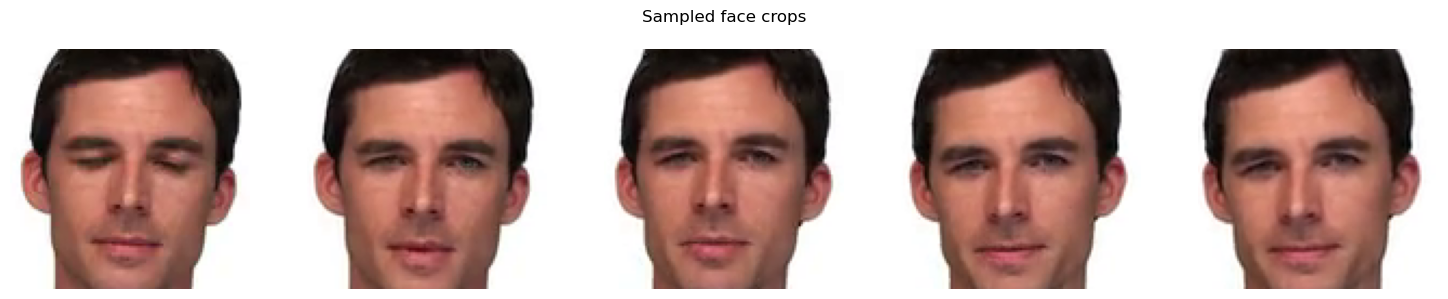

In [14]:
def aggregate_frames(frame_probabilities):
    """Average T probability vectors and renormalize."""
    # SOLUTION 5
    probabilities = np.asarray(frame_probabilities, dtype=np.float32)
    if probabilities.ndim != 2 or len(probabilities) == 0:
        raise ValueError("Expected a non-empty T × C probability matrix")
    mean_probability = probabilities.mean(axis=0)
    return mean_probability / mean_probability.sum()

def predict_video(video_path, n_frames=5):
    frames = sample_frames(video_path, n_frames=n_frames)
    faces = [center_face_crop(frame) for frame in frames]
    frame_probabilities = []
    for face in faces:
        raw = video_classifier(face, top_k=None)
        frame_probabilities.append(canonicalize_distribution(raw))
    return aggregate_frames(frame_probabilities), faces, frame_probabilities

# Optional live test (requires data and a loaded model).
if MODE in {"live", "hybrid"} and len(metadata):
    p_video_example, faces, frame_ps = predict_video(example_path)
    show_frames(faces)
    print(probability_dict(p_video_example))


### TODO 6 — Visualize temporal variation

Plot the probability of every emotion across the sampled frames. Is the mean hiding instability?


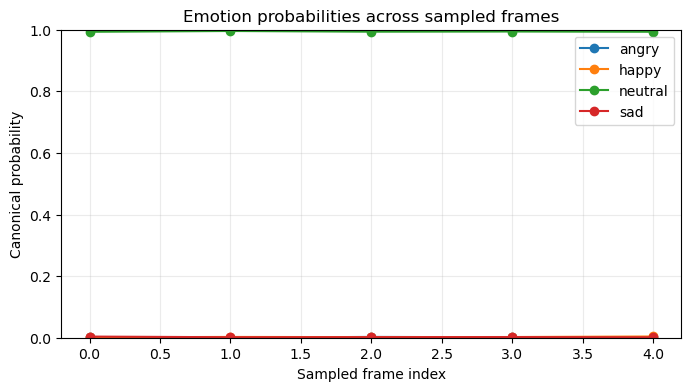

In [15]:
def plot_frame_probabilities(frame_probabilities):
    values = np.vstack(frame_probabilities)
    # SOLUTION 6
    frame_table = pd.DataFrame(values, columns=CANONICAL_LABELS)
    ax = frame_table.plot(marker="o", figsize=(8, 4))
    ax.set(
        xlabel="Sampled frame index",
        ylabel="Canonical probability",
        title="Emotion probabilities across sampled frames",
        ylim=(0, 1),
    )
    ax.grid(alpha=0.25)
    plt.show()

if "frame_ps" in globals():
    plot_frame_probabilities(frame_ps)


## 5. Build or load the prediction table

Expected precomputed files:

- `audio_predictions.csv`
- `video_predictions.csv`

Each contains: `filename`, `ground_truth`, and `p_angry`, `p_happy`, `p_neutral`, `p_sad`. Precomputed predictions must come from exactly the same checkpoint versions and preprocessing used in the live demonstration.


In [16]:
PROB_COLS = [f"p_{x}" for x in CANONICAL_LABELS]

def load_precomputed_predictions():
    audio = pd.read_csv(PREDICTIONS_DIR / "audio_predictions.csv")
    video = pd.read_csv(PREDICTIONS_DIR / "video_predictions.csv")
    return audio.merge(video, on=["filename", "ground_truth"], suffixes=("_audio", "_video"))

def run_live_predictions(df, limit=None):
    rows = []
    work = df.head(limit) if limit else df
    for row in work.itertuples(index=False):
        pa = predict_audio(row.path)
        pv, _, _ = predict_video(row.path)
        item = {"filename": row.filename, "ground_truth": row.emotion}
        item.update({f"p_{label}_audio": float(pa[i]) for i, label in enumerate(CANONICAL_LABELS)})
        item.update({f"p_{label}_video": float(pv[i]) for i, label in enumerate(CANONICAL_LABELS)})
        rows.append(item)
    return pd.DataFrame(rows)

if MODE == "precomputed":
    predictions = load_precomputed_predictions()
elif MODE == "hybrid":
    try:
        predictions = load_precomputed_predictions()
        print("Using precomputed predictions for evaluation.")
    except FileNotFoundError:
        predictions = run_live_predictions(metadata, MAX_LIVE_CLIPS)
        print("Precomputed files absent; evaluated a small live subset.")
else:
    predictions = run_live_predictions(metadata, MAX_LIVE_CLIPS)

display(predictions.head())


Using precomputed predictions for evaluation.


,filename,ground_truth,p_angry_audio,p_happy_audio,p_neutral_audio,p_sad_audio,predicted_label_audio,confidence_audio,retained_probability_mass_audio,model_name_audio,inference_seconds_cpu_audio,p_angry_video,p_happy_video,p_neutral_video,p_sad_video,predicted_label_video,confidence_video,retained_probability_mass_video,model_name_video,inference_seconds_cpu_video
0,01-01-01-01-01-01-01.mp4,neutral,0.033634,0.024282,0.941846,0.000238,neutral,0.941846,1.0,superb/wav2vec2-base-superb-er,1.094822,0.001410,0.002476,0.994032,0.002082,neutral,0.994032,0.994686,trpakov/vit-face-expression,0.990982
1,01-01-01-01-01-01-02.mp4,neutral,0.069783,0.012025,0.918154,0.000037,neutral,0.918154,1.0,superb/wav2vec2-base-superb-er,0.678717,0.004457,0.000516,0.977138,0.017889,neutral,0.977138,0.976964,trpakov/vit-face-expression,0.743830
2,01-01-01-01-01-01-03.mp4,neutral,0.101112,0.026685,0.872186,0.000018,neutral,0.872186,1.0,superb/wav2vec2-base-superb-er,0.456961,0.071648,0.000000,0.827762,0.100590,neutral,0.827762,0.755844,trpakov/vit-face-expression,0.563229
3,01-01-01-01-01-01-04.mp4,neutral,0.106918,0.017356,0.875700,0.000026,neutral,0.875700,1.0,superb/wav2vec2-base-superb-er,0.504514,0.004995,0.002089,0.990573,0.002343,neutral,0.990573,0.981639,trpakov/vit-face-expression,0.645179
4,01-01-01-01-01-01-05.mp4,neutral,0.057727,0.070692,0.871318,0.000263,neutral,0.871318,1.0,superb/wav2vec2-base-superb-er,0.872874,0.017527,0.000872,0.979352,0.002250,neutral,0.979352,0.839734,trpakov/vit-face-expression,0.802099


## 6. Which modality is better?

Use accuracy and macro F1. With a small demonstration subset, interpret both cautiously and always inspect class support and confusion matrices.


In [17]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

def matrix_from_table(df, modality):
    return df[[f"p_{label}_{modality}" for label in CANONICAL_LABELS]].to_numpy()

def labels_from_probabilities(P):
    return np.asarray(CANONICAL_LABELS)[np.asarray(P).argmax(axis=1)]

P_AUDIO = matrix_from_table(predictions, "audio")
P_VIDEO = matrix_from_table(predictions, "video")
Y_TRUE = predictions["ground_truth"].to_numpy()

# SOLUTION 7
Y_AUDIO = labels_from_probabilities(P_AUDIO)
Y_VIDEO = labels_from_probabilities(P_VIDEO)

metrics = pd.DataFrame([
    {
        "model": "audio",
        "accuracy": accuracy_score(Y_TRUE, Y_AUDIO),
        "macro_f1": f1_score(Y_TRUE, Y_AUDIO, average="macro", zero_division=0),
    },
    {
        "model": "video",
        "accuracy": accuracy_score(Y_TRUE, Y_VIDEO),
        "macro_f1": f1_score(Y_TRUE, Y_VIDEO, average="macro", zero_division=0),
    },
])
display(metrics)


,model,accuracy,macro_f1
0,audio,0.4625,0.375950
1,video,0.6375,0.627148


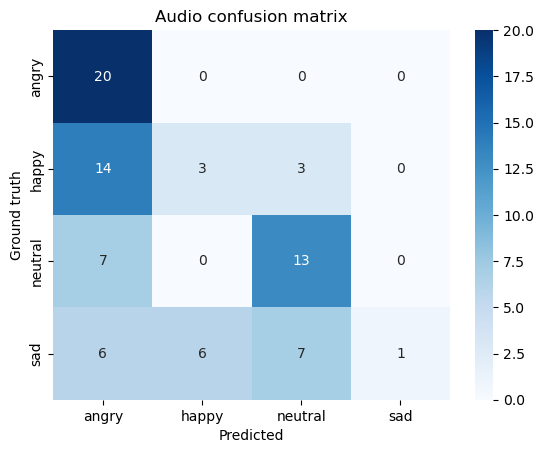

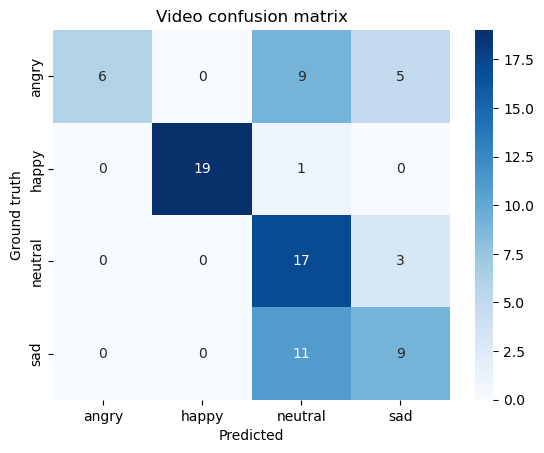

In [18]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=CANONICAL_LABELS)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CANONICAL_LABELS, yticklabels=CANONICAL_LABELS)
    plt.xlabel("Predicted"); plt.ylabel("Ground truth"); plt.title(title)
    plt.show()

# SOLUTION 8
plot_confusion(Y_TRUE, Y_AUDIO, "Audio confusion matrix")
plot_confusion(Y_TRUE, Y_VIDEO, "Video confusion matrix")


## 7. Combine modalities: fixed late fusion

Let $p_A$ be the audio distribution and $p_V$ the video distribution:

$$p_{AV}(y)=\alpha p_A(y)+(1-\alpha)p_V(y), \quad 0\leq\alpha\leq1.$$

Here, $\alpha=1$ means audio only and $\alpha=0$ means video only.


In [19]:
def multimodal_fusion(p_audio, p_video, alpha=0.5):
    # SOLUTION 9
    if not 0.0 <= alpha <= 1.0:
        raise ValueError("alpha must lie in [0, 1]")
    p_audio = np.asarray(p_audio, dtype=np.float32)
    p_video = np.asarray(p_video, dtype=np.float32)
    if p_audio.shape != p_video.shape:
        raise ValueError("Audio and video probabilities must have the same shape")
    return alpha * p_audio + (1.0 - alpha) * p_video

P_FUSED_05 = multimodal_fusion(P_AUDIO, P_VIDEO, alpha=0.5)
Y_FUSED_05 = labels_from_probabilities(P_FUSED_05)

fusion_05_metrics = {
    "model": "fusion alpha=0.5",
    "accuracy": accuracy_score(Y_TRUE, Y_FUSED_05),
    "macro_f1": f1_score(Y_TRUE, Y_FUSED_05, average="macro", zero_division=0),
}
display(pd.concat([metrics, pd.DataFrame([fusion_05_metrics])], ignore_index=True))


,model,accuracy,macro_f1
0,audio,0.4625,0.375950
1,video,0.6375,0.627148
2,fusion alpha=0.5,0.6875,0.660830


## 8. Is 50/50 fusion optimal?

Tune $\alpha$ on a **development set**, never on the test set used for the final result. In this compact workshop we visualize the curve on the available subset; treat the best value as exploratory, not a valid generalization estimate.


,alpha,accuracy,macro_f1
0,0.0,0.6375,0.627148
1,0.1,0.6500,0.644771
2,0.2,0.6625,0.660570
3,0.3,0.7000,0.697938
4,0.4,0.7500,0.746335
5,0.5,0.6875,0.660830
6,0.6,0.6000,0.546819
7,0.7,0.5000,0.411063
8,0.8,0.4875,0.394271
9,0.9,0.4625,0.374362


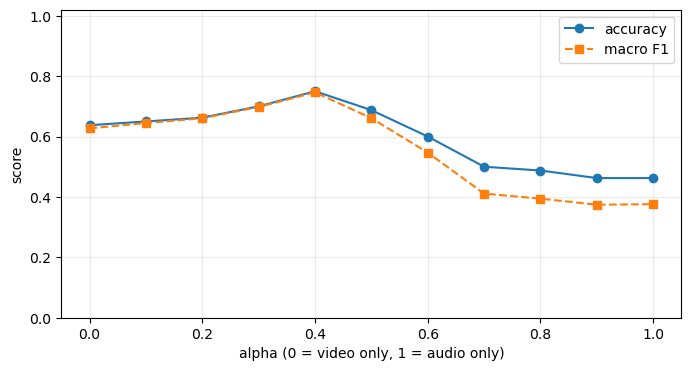

Exploratory best alpha by macro F1: 0.4


In [20]:
alphas = np.linspace(0, 1, 11)
alpha_results = []

for alpha in alphas:
    # SOLUTION 10
    P_alpha = multimodal_fusion(P_AUDIO, P_VIDEO, alpha=alpha)
    Y_alpha = labels_from_probabilities(P_alpha)
    alpha_results.append({
        "alpha": float(alpha),
        "accuracy": accuracy_score(Y_TRUE, Y_alpha),
        "macro_f1": f1_score(Y_TRUE, Y_alpha, average="macro", zero_division=0),
    })

alpha_results = pd.DataFrame(alpha_results)
display(alpha_results)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alpha_results["alpha"], alpha_results["accuracy"], "o-", label="accuracy")
ax.plot(alpha_results["alpha"], alpha_results["macro_f1"], "s--", label="macro F1")
ax.set(xlabel="alpha (0 = video only, 1 = audio only)", ylabel="score", ylim=(0, 1.02))
ax.grid(alpha=.25); ax.legend(); plt.show()

best_row = alpha_results.loc[alpha_results["macro_f1"].idxmax()]
print(f"Exploratory best alpha by macro F1: {best_row.alpha:.1f}")


## 9. When modalities disagree

We will examine two notions:

1. **hard disagreement:** the two argmax labels differ;
2. **distribution disagreement:** $D(x)=1-p_A^\top p_V$.

The second measure is easy to understand but is not a calibrated uncertainty estimate.


In [21]:
def disagreement_score(p_audio, p_video):
    # SOLUTION 11
    p_audio = np.asarray(p_audio)
    p_video = np.asarray(p_video)
    if p_audio.shape != p_video.shape:
        raise ValueError("Audio and video probabilities must have the same shape")
    return 1.0 - np.sum(p_audio * p_video, axis=-1)

analysis = predictions[["filename", "ground_truth"]].copy()
analysis["audio_prediction"] = Y_AUDIO
analysis["video_prediction"] = Y_VIDEO
analysis["hard_disagreement"] = Y_AUDIO != Y_VIDEO
analysis["disagreement_score"] = disagreement_score(P_AUDIO, P_VIDEO)
analysis["audio_confidence"] = P_AUDIO.max(axis=1)
analysis["video_confidence"] = P_VIDEO.max(axis=1)

display(analysis.sort_values("disagreement_score", ascending=False).head(10))


,filename,ground_truth,audio_prediction,video_prediction,hard_disagreement,disagreement_score,audio_confidence,video_confidence
38,01-01-03-02-02-02-04.mp4,happy,angry,happy,True,0.989814,0.987953,0.995413
29,01-01-03-01-02-02-04.mp4,happy,neutral,happy,True,0.989385,0.546916,0.996825
37,01-01-03-02-02-02-02.mp4,happy,angry,happy,True,0.989041,0.965400,0.758719
51,01-01-04-01-02-02-06.mp4,sad,angry,sad,True,0.983228,0.513928,0.980424
30,01-01-03-01-02-02-05.mp4,happy,angry,happy,True,0.975968,0.941124,0.978354
58,01-01-04-02-02-02-04.mp4,sad,angry,sad,True,0.969596,0.935134,0.957750
59,01-01-04-02-02-02-06.mp4,sad,happy,sad,True,0.967608,0.952353,0.885752
70,01-01-05-01-02-02-05.mp4,angry,angry,neutral,True,0.958541,0.947669,0.979386
33,01-01-03-02-01-01-02.mp4,happy,angry,happy,True,0.953749,0.832505,0.798021
64,01-01-05-01-01-01-05.mp4,angry,angry,neutral,True,0.937245,0.953973,0.961123


### TODO 12 — Inspect a failure case

Choose one high-disagreement clip. Play it and answer:

- Which modality would you trust, and why?
- Is either model using a spurious cue?
- Is the dataset label itself unambiguous?
- Does confidence appear to reflect reliability?


In [22]:
# SOLUTION 12: automatically inspect the strongest disagreement.
selected_row = analysis.sort_values("disagreement_score", ascending=False).iloc[0]
SELECTED_FILENAME = selected_row["filename"]
REFLECTION = (
    "The modality to trust should depend on observable signal quality and domain knowledge, "
    "not only on the largest softmax value. Facial pose, a weak crop, vocal intensity, or "
    "acted delivery may be spurious cues. The RAVDESS category is an intended performance "
    "label rather than an objective measurement of an internal emotional state."
)

if len(metadata) and (metadata.filename == SELECTED_FILENAME).any():
    selected_path = metadata.loc[metadata.filename == SELECTED_FILENAME, "path"].iloc[0]
    display(Video(str(selected_path), embed=True, width=560))

display(selected_row.to_frame("value"))
print(REFLECTION)


,value
filename,01-01-03-02-02-02-04.mp4
ground_truth,happy
audio_prediction,angry
video_prediction,happy
hard_disagreement,True
disagreement_score,0.989814
audio_confidence,0.987953
video_confidence,0.995413


The modality to trust should depend on observable signal quality and domain knowledge, not only on the largest softmax value. Facial pose, a weak crop, vocal intensity, or acted delivery may be spurious cues. The RAVDESS category is an intended performance label rather than an objective measurement of an internal emotional state.


## Bonus A — Confidence-aware fusion

Use each modality's maximum softmax probability as a dynamic weight:

$$\alpha(x)=\frac{\max p_A}{\max p_A+\max p_V}.$$

This is a useful experiment, but softmax confidence is often miscalibrated. A confidently wrong modality may dominate.


In [23]:
def confidence_aware_fusion(P_audio, P_video, eps=1e-8):
    # BONUS SOLUTION A
    P_audio = np.asarray(P_audio, dtype=np.float32)
    P_video = np.asarray(P_video, dtype=np.float32)
    if P_audio.shape != P_video.shape:
        raise ValueError("Audio and video probabilities must have the same shape")
    confidence_audio = P_audio.max(axis=-1, keepdims=True)
    confidence_video = P_video.max(axis=-1, keepdims=True)
    alpha = confidence_audio / (confidence_audio + confidence_video + eps)
    return alpha * P_audio + (1.0 - alpha) * P_video

P_CONF = confidence_aware_fusion(P_AUDIO, P_VIDEO)
Y_CONF = labels_from_probabilities(P_CONF)

confidence_metrics = pd.DataFrame([{
    "model": "confidence-aware fusion",
    "accuracy": accuracy_score(Y_TRUE, Y_CONF),
    "macro_f1": f1_score(Y_TRUE, Y_CONF, average="macro", zero_division=0),
}])
display(confidence_metrics)


,model,accuracy,macro_f1
0,confidence-aware fusion,0.6875,0.666893


## Bonus B — Create an incongruent audiovisual sample

Conceptually pair the video probabilities from one clip with the audio probabilities from another clip expressing a different emotion. No media editing is required to test the fusion rule.


In [24]:
# BONUS SOLUTION B: find two clips with different ground-truth emotions.
if len(predictions) < 2:
    raise ValueError("At least two prediction rows are required")

i, j = None, None
for first in range(len(predictions)):
    candidates = np.flatnonzero(
        predictions["ground_truth"].to_numpy() != predictions.iloc[first].ground_truth
    )
    if len(candidates):
        i, j = first, int(candidates[0])
        break

if i is None:
    raise ValueError("The prediction table contains only one ground-truth emotion")

p_incongruent = multimodal_fusion(P_AUDIO[j], P_VIDEO[i], alpha=0.5)
print("Face source:", predictions.iloc[i].filename, predictions.iloc[i].ground_truth)
print("Voice source:", predictions.iloc[j].filename, predictions.iloc[j].ground_truth)
print("Fused result:", probability_dict(p_incongruent))

INCONGRUENCE_REFLECTION = (
    "A fixed fusion rule must return a distribution even though the paired signals are "
    "mutually incompatible. Detecting cross-modal inconsistency and abstaining, requesting "
    "context, or reporting modality-specific evidence may be more defensible than forcing "
    "a single emotion label."
)
print(INCONGRUENCE_REFLECTION)


Face source: 01-01-01-01-01-01-01.mp4 neutral
Voice source: 01-01-03-01-01-01-01.mp4 happy
Fused result: {'angry': 0.0267, 'happy': 0.2569, 'neutral': 0.7136, 'sad': 0.0029}
A fixed fusion rule must return a distribution even though the paired signals are mutually incompatible. Detecting cross-modal inconsistency and abstaining, requesting context, or reporting modality-specific evidence may be more defensible than forcing a single emotion label.


## What did we learn?

1. Audio and facial behavior provide complementary—but imperfect—evidence.
2. More modalities do not automatically produce a better prediction.
3. Label-space harmonization is part of the model, not bookkeeping.
4. Fusion weights should be selected without leaking test information.
5. Model confidence is not the same as reliability.
6. Temporal averaging can hide frame-level instability.
7. Acted benchmarks do not represent all people, cultures, languages, or real contexts.
8. A system can combine probabilities without understanding why modalities conflict.

### Final question

> A human can sometimes decide whether to trust the face, voice, words, or context. How can a multimodal AI system learn **when—and why—to trust each modality**?


## Instructor preparation checklist

- Curate 80–150 RAVDESS speech clips, balanced across the four canonical emotions and actors.
- Preserve the RAVDESS license/readme and document the exact subset.
- Cache both selected model snapshots on every lab machine.
- Test a fresh environment with network disabled.
- Precompute audio and frame-aggregated video probabilities using the same commits and preprocessing.
- Record model repository, revision/commit, license, exact parameter count, label map, and expected disk footprint.
- Verify FFmpeg/OpenCV decoding and 16 kHz audio resampling.
- Keep actor identities disjoint across development and test if reporting tuned-fusion results.
- Prepare two or three known disagreement examples and one incongruent pairing.
- Do not present benchmark predictions as measurements of a participant's internal emotion.

### Suggested folder layout

```text
workshop/
├── Multimodal_Emotion_Recognition_Workshop.ipynb
└── data/
    ├── ravdess_subset/
    │   └── *.mp4
    └── precomputed/
        ├── audio_predictions.csv
        └── video_predictions.csv
```


## Sources and model cards to review before delivery

- RAVDESS dataset: Livingstone & Russo; official Zenodo record `1188976`.
- Hugging Face model cards for every selected checkpoint.
- `superb/wav2vec2-base-superb-er` and `superb/wav2vec2-large-superb-er`.
- `speechbrain/emotion-recognition-wav2vec2-IEMOCAP`.
- `trpakov/vit-face-expression` and alternative facial-expression checkpoints listed above.
- Transformers documentation for audio and image classification pipelines.

Model repositories can change. Pin a tested revision and verify parameter counts, labels, preprocessing, license, and availability shortly before the workshop.
